# 深度理解LangGraph核心-Graph

在了解了LangGraph中如何构建Agent智能体之后，接下来就要进入LangGraph的重头戏——Graph。Graph是LangGraph的核心，它以有向无环图的方式来串联多个Agent，构建更复杂的Agent大模型应用，形成更复杂的工作流。并且提供了很多产品级的特性，保证这些应用可以更稳定高效的执行。

# 一、理解什么是Graph图

Graph是LangGraph的基本构建模块，它是一个有向无环图(DAG)，用于描述任务之间的依赖关系。

主要包含三个基本的元素：
- **State**：在整个应用当中共享的一种数据结构。
- **Node**：一个处理数据的节点。LangGraph中通常是一个Python的函数，以State为输入，经过一些操作后，返回更新后的State。
- **Edge**：表示Node之间的依赖关系。LangGraph中通常也是一个Python函数，根据当前State来决定接下来执行哪个Node。

接下来用一个最简单的案例，来看一下Graph的基本用法。

In [ ]:
# 安装依赖
!pip install -U langgraph

In [1]:
from typing import TypedDict
from langgraph.constants import END, START
from langgraph.graph import StateGraph

class InputState(TypedDict):
    user_input: str

class OutputState(TypedDict):
    graph_output: str

class OverallState(TypedDict):
    foo: str
    user_input: str
    graph_output: str

class PrivateState(TypedDict):
    bar: str

def node_1(state: InputState) -> OverallState:  # Write to OverallState
    return {"foo": state["user_input"] + ">天气"}

def node_2(state: OverallState) -> PrivateState:  # Read from OverallState, write to PrivateState
    return {"bar": state["foo"] + ">非常"}

def node_3(state: PrivateState) -> OutputState:  # Read from PrivateState, write to OutputState
    return {"graph_output": state["bar"] + ">好"}

# 构建图
builder = StateGraph(OverallState, input=InputState, output=OutputState)

# 添加Node
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# 添加Edge
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

# 编译图
graph = builder.compile()

# 调用图
result = graph.invoke({"user_input": "今天"})
print(result)

{'graph_output': '今天>天气>非常>好'}


C:\Users\Qinghe\AppData\Local\Temp\ipykernel_30788\655271177.py:29: LangGraphDeprecatedSinceV05: `input` is deprecated and will be removed. Please use `input_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  builder = StateGraph(OverallState, input=InputState, output=OutputState)
C:\Users\Qinghe\AppData\Local\Temp\ipykernel_30788\655271177.py:29: LangGraphDeprecatedSinceV05: `output` is deprecated and will be removed. Please use `output_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  builder = StateGraph(OverallState, input=InputState, output=OutputState)


这个案例当中，请求的参数从固定的START传入，依次经过三个节点处理，每个节点的处理结果都会被保存到不同的state当中，最后进入到END节点结束。

如果你觉得这个流程不够明显，还可以直接用真正的图来看看请求是如何处理的。

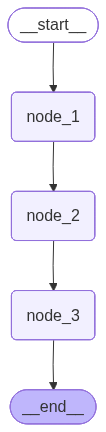

In [2]:
from IPython.display import Image, display

# draw_mermaid方法可以打印出Graph的mermaid代码
display(Image(graph.get_graph().draw_mermaid_png()))

可以看到，一个Graph中，可以通过对Node和Edge的灵活组合，形成各种复杂的流程。接下来，我们就是要接入Agent，来完成各种复杂的任务。

在构建复杂任务之前，我们先来仔细看看Graph中的这三个主要组件。

# 1、State 状态

State是所有节点共享的状态，它是一个字典，包含了所有节点的状态。有几个需要注意的地方：

State形式上，可以是TypedDict字典，也可以是Pydantic中的一个BaseModel。

In [ ]:
from pydantic import BaseModel

# The overall state of the graph (this is the public state shared across nodes)
class OverallState(BaseModel):
    a: str


# 这两种实现，本质上没有太多的区别。

State中定义的属性，通常不需要指定默认值。如果需要默认值，可以通过在START节点后，定义一个node来指定默认值。

In [ ]:
def node(state: OverallState):
    return {"a": "goodbye"}

State中的属性，除了可以修改值之外，也可以定义一些操作，来指定如何更新State中的值。

In [ ]:
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    list_field: Annotated[list[int],add]
    extra_field: int

此时，如果有⼀个node，返回了State中更新的值， 那么messages和list_field的值就会添加到原有的旧集合中，
⽽extra_field的值则会被替换。

In [3]:
from operator import add
from typing import Annotated, TypedDict
from langchain_core.messages import AnyMessage, AIMessage
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    list_field: Annotated[list[int], add]
    extra_field: int

def node1(state: State):
    new_message = AIMessage("Hello!")
    return {"messages": [new_message], "list_field": [10], "extra_field": 10}

def node2(state: State):
    new_message = AIMessage("LangGraph!")
    return {"messages": [new_message], "list_field": [20], "extra_field": 20}

graph = (
    StateGraph(State)
    .add_node("node1", node1)
    .add_node("node2", node2)
    .set_entry_point("node1")
    .add_edge("node1", "node2")
    .compile()
)

input_message = {"role": "user", "content": "Hi"}
result = graph.invoke({"messages": [input_message], "list_field": [1, 2, 3]})
print(result)

for message in result["messages"]:
    print(message)
print("extra_field:", result["extra_field"])

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='b460ceab-dde6-4eda-acb5-3565a52b16a1'), AIMessage(content='Hello!', additional_kwargs={}, response_metadata={}, id='d2e898f5-5511-4cb9-b911-38344949cfed', tool_calls=[], invalid_tool_calls=[]), AIMessage(content='LangGraph!', additional_kwargs={}, response_metadata={}, id='99783873-92f5-45a1-a44a-24e93b641980', tool_calls=[], invalid_tool_calls=[])], 'list_field': [1, 2, 3, 10, 20], 'extra_field': 20}
content='Hi' additional_kwargs={} response_metadata={} id='b460ceab-dde6-4eda-acb5-3565a52b16a1'
content='Hello!' additional_kwargs={} response_metadata={} id='d2e898f5-5511-4cb9-b911-38344949cfed' tool_calls=[] invalid_tool_calls=[]
content='LangGraph!' additional_kwargs={} response_metadata={} id='99783873-92f5-45a1-a44a-24e93b641980' tool_calls=[] invalid_tool_calls=[]
extra_field: 20


在LangGraph的应用当中，State通常都会要保存聊天消息。为此，LangGraph中还提供了一个`langgraph.graph.MessagesState`，可以用来快速保存消息。

他的声明⽅式就是这样的：
```bash
class MessagesState(TypedDict):
messages: Annotated[list[AnyMessage], add_messages]

```

然后，对于Messages，也可以⽤序列化的⽅式来声明，例如下⾯两种⽅式都是可以的
```bash

{"messages": [HumanMessage(content="message")]}
{"messages": [{"type": "user", "content": "message"}]}

```

# 2、Node 节点

Node是图中的一个处理数据的节点。也有以下几个需要注意的地方：

- 在LangGraph中，Node通常是一个Python的函数，它接受一个State对象作为输入，返回一个State对象作为输出。
- 每个Node都有一个唯一的名称，通常是一个字符串。如果没有提供名称，LangGraph会自动生成一个和函数名一样的名称。
- 在具体实现时，通常包含两个具体的参数，第一个是State，这个是必选的。第二个是一个可选的配置项config。这里面包含了一些节点运行的配置参数。
- LangGraph对每个Node提供了缓存机制。只要Node的传入参数相同，LangGraph就会优先从缓存当中获取Node的执行结果。从而提升Node的运行速度。

In [5]:
import time
from typing import TypedDict
from langchain_core.runnables import RunnableConfig
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.types import CachePolicy
from langgraph.cache.memory import InMemoryCache  # 是langgraph中的，而不是langchain中的

# 配置状态
class State(TypedDict):
    number: int
    user_id: str

# 配置信息
class ConfigSchema(TypedDict):
    user_id: str

def node_1(state: State, config: RunnableConfig):
    time.sleep(3)
    user_id = config["configurable"]["user_id"]
    return {"number": state["number"] + 1, "user_id": user_id}

builder = StateGraph(State, config_schema=ConfigSchema)
# Node缓存5秒
builder.add_node("node1", node_1, cache_policy=CachePolicy(ttl=5))
builder.add_edge(START, "node1")
builder.add_edge("node1", END)

graph = builder.compile(cache=InMemoryCache())

print(graph.invoke({"number": 5}, config={"configurable": {"user_id": "123"}}, stream_mode='updates'))
# [{'node1': {'number': 6, 'user_id': '123'}}]

# node入参相同，就会走缓存
print(graph.invoke({"number": 5}, config={"configurable": {"user_id": "456"}}, stream_mode='updates'))
# [{'node1': {'number': 6, 'user_id': '123'}, '__metadata__': {'cached': True}}]

C:\Users\Qinghe\AppData\Local\Temp\ipykernel_30788\2969984071.py:23: LangGraphDeprecatedSinceV10: `config_schema` is deprecated and will be removed. Please use `context_schema` instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  builder = StateGraph(State, config_schema=ConfigSchema)


[{'node1': {'number': 6, 'user_id': '123'}}]
[{'node1': {'number': 6, 'user_id': '123'}, '__metadata__': {'cached': True}}]


对于Node，LangGraph除了提供缓存机制，还提供了重试机制。

In [ ]:
from langgraph.types import RetryPolicy

# 可以针对单个节点指定重试策略
builder.add_node("node1", node_1, retry=RetryPolicy(max_attempts=4))

# 另外，也可以针对某一次任务调用指定递归限制
print(graph.invoke(xxxxx, config={"recursion_limit": 25}))

# 3、Edge 边

在Graph图中，通过Edge(边)把Node(节点)连接起来，从而决定State应该如何在Graph中传递。LangGraph中也提供了非常灵活的构建方式。

## 普通Edge和EntryPoint

Edge通常是用来把两个Node连接起来，形成逻辑处理路线。LangGraph中提供了两个默认的Node，START和END，用来作为Graph的入口和出口。同时，也可以自行指定EntryPoint。

In [ ]:
builder = StateGraph(State)
builder.set_entry_point("node1")
builder.set_finish_point("node2")

# 普通Edge
# graph.add_edge("node_1", "node_2")

## 条件Edge和EntryPoint

我们也可以添加带有条件判断的Edge和EntryPoint，用来动态构建更复杂的工作流程。具体实现时，可以指定一个函数，函数的返回值就可以是下一个Node的名称。

In [11]:
from typing import TypedDict
from langchain_core.runnables import RunnableConfig
from langgraph.constants import START, END
from langgraph.graph import StateGraph

# 配置状态
class State(TypedDict):
    number: int

def node_1(state: State, config: RunnableConfig):
    return {"number": state["number"] + 1}

builder = StateGraph(State)
builder.add_node("node1", node_1)

def routing_func(state: State) -> str:
    if state["number"] > 5:
        return "node1"
    else:
        return END

builder.add_edge("node1", END)
builder.add_conditional_edges(START, routing_func)

graph = builder.compile()
print(graph.invoke({"number": 7}))
# {'number': 8}

{'number': 8}


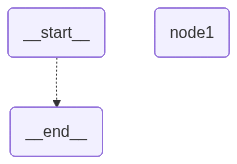

In [12]:
# 补充看⼀下Graph的结构
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

另外，如果不想在路由函数中写入过多具体的节点名称，也可以在函数中返回一个自定义的结果，然后将这个结果解析到某一个具体的Node上。

In [7]:
def routing_func(state: State) -> bool:
    if state["number"] > 5:
        return True
    else:
        return False

builder.add_conditional_edges(START, routing_func, {True: "node_a", False: "node_b"})

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


ValueError: Branch with name `routing_func` already exists for node `__start__`

## Send动态路由

在条件边中，如果希望一个Node后同时路由到多个Node，就可以返回Send动态路由的方式实现。Send对象可传入两个参数，第一个是下一个Node的名称，第二个是Node的输入。

In [13]:
from operator import add
from typing import TypedDict, Annotated
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.types import Send

# 配置状态
class State(TypedDict):
    messages: Annotated[list[str], add]

class PrivateState(TypedDict):
    msg: str

def node_1(state: PrivateState):
    res = state["msg"] + "!"
    return {"messages": [res]}

builder = StateGraph(State)
builder.add_node("node1", node_1)

def routing_func(state: State):
    result = []
    for message in state["messages"]:
        result.append(Send("node1", {"msg": message}))
    return result

# 通过路由函数，将消息中每个字符串分别传入node1处理
builder.add_conditional_edges(START, routing_func, ["node1"])
builder.add_edge("node1", END)

graph = builder.compile()
print(graph.invoke({"messages": ["hello", "world", "hello", "graph"]}))
# {'messages': ['hello', 'world', 'hello', 'graph', 'hello!', 'world!', 'hello!', 'graph!']}

{'messages': ['hello', 'world', 'hello', 'graph', 'hello!', 'world!', 'hello!', 'graph!']}


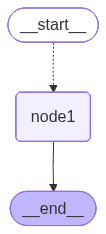

In [14]:
# 补充看⼀下Graph的结构
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

## Command命令

通常，Graph中一个典型的业务步骤是State进入一个Node处理。在Node中先更新State状态，然后再通过Edges传递给下一个Node。如果希望将这两个步骤合并为一个命令，那么还可以使用Command命令。

In [17]:
from operator import add
from typing import TypedDict, Annotated
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.types import Command

# 配置状态
class State(TypedDict):
    messages: Annotated[list[str], add]

def node_1(state: State):
    new_message = []
    for message in state["messages"]:
        new_message.append(message + "!")
    return Command(
        goto=END,
        update={"messages": new_message}
    )

builder = StateGraph(State)
builder.add_node("node1", node_1)
builder.add_edge(START, "node1")

# node1中通过Command同时集成了更新State和指定下个Node
graph = builder.compile()
print(graph.invoke({"messages": ["hello", "world", "hello", "graph"]}))
# {'messages': ['hello', 'world', 'hello', 'graph', 'hello!', 'world!', 'hello!', 'graph!']}



{'messages': ['hello', 'world', 'hello', 'graph', 'hello!', 'world!', 'hello!', 'graph!']}


# 4、子图

在LangGraph中，一个Graph除了可以单独使用，还可以作为一个Node，嵌入到另一个Graph中。这种用法就称为子图。通过子图，我们可以更好的重用Graph，构建更复杂的工作流。尤其在构建多Agent时，非常有用。在大型项目中，通常都是由一个团队专门开发Agent，再通过其他团队来完整Agent整合。

使用子图时，基本和使用Node没有太多的区别。唯一需要注意的是，当触发了SubGraph代表的Node后，实际上是相当于重新调用了一次subgraph.invoke(state)方法。

In [18]:
from operator import add
from typing import TypedDict, Annotated
from langgraph.constants import END
from langgraph.graph import StateGraph, MessagesState, START

class State(TypedDict):
    messages: Annotated[list[str], add]

# Subgraph
def sub_node_1(state: State) -> MessagesState:
    return {"messages": ["response from subgraph"]}

subgraph_builder = StateGraph(State)
subgraph_builder.add_node("sub_node_1", sub_node_1)
subgraph_builder.add_edge(START, "sub_node_1")
subgraph = subgraph_builder.compile()

# Parent graph
builder = StateGraph(State)
builder.add_node("subgraph_node", subgraph)
builder.add_edge(START, "subgraph_node")
builder.add_edge("subgraph_node", END)
graph = builder.compile()

print(graph.invoke({"messages": ["hello subgraph"]}))
# 结果hello subgraph会出现两次。这是因为在subgraph_node中默认调用了一次subgraph.invoke(state)方法。主图里也调用了一次invoke。这就会往state中添加两次语句
# {'messages': ['hello subgraph', 'hello subgraph', 'response from subgraph']}

{'messages': ['hello subgraph', 'hello subgraph', 'response from subgraph']}


# 5、图的Stream支持

和调用大模型相似，Graph除了可以通过invoke方法进行直接调用外，也支持通过stream()方法进行流式调用。不过大模型的流式调用是依次返回大模型响应的Token。而Graph的流式输出则是依次返回State的数据处理步骤。graph提供了stream()方法进行同步的流式调用，也提供了astream()方法进行异步的流式调用。

LangGraph支持几种不同的stream mode：
- **values**：在图的每一步之后流式传输状态的完整值。
- **updates**：在图的每一步之后，将更新内容流式传输到状态。如果在同一步骤中进行了多次更新(例如，运行了多个节点)，这些更新将分别进行流式传输。
- **custom**：从图节点内部流式传输自定义数据。通常用于调试。
- **messages**：从任何调用大语言模型(LLM)的图节点中，流式传输二元组(LLM的Token, 元数据)
- **debug**：在图的执行过程中尽可能多地传输信息。用得比较少。

In [ ]:
# stream 示例
for chunk in graph.stream({"messages": ["hello subgraph"]}, stream_mode="debug"):
    print(chunk)



{'step': 1, 'timestamp': '2026-05-23T10:45:09.343053+00:00', 'type': 'task', 'payload': {'id': '43ae8547-2cd4-ed2f-a073-119d882e9a41', 'name': 'subgraph_node', 'input': {'messages': ['hello subgraph']}, 'triggers': ('branch:to:subgraph_node',)}}
{'step': 1, 'timestamp': '2026-05-23T10:45:09.347059+00:00', 'type': 'task_result', 'payload': {'id': '43ae8547-2cd4-ed2f-a073-119d882e9a41', 'name': 'subgraph_node', 'error': None, 'result': {'messages': ['hello subgraph', 'response from subgraph']}, 'interrupts': []}}


values、updates、debug输出模式，使⽤之前案例验证，就能很快感受到其中的区别。

messages输出模式，由于在之前案例中并没有调⽤⼤模型，所以不会有输出结果。

⽽custom输出模式，可以⾃定义输出内容。在Node节点内或者Tools⼯具内，通过get_stream_writer()⽅法获取⼀个StreamWriter对象，然后使⽤write()⽅法将⾃定义数据写⼊流中。  

In [20]:
from typing import TypedDict
from langgraph.config import get_stream_writer
from langgraph.graph import StateGraph, START

class State(TypedDict):
    query: str
    answer: str

def node(state: State):
    writer = get_stream_writer()
    writer({"自定义key": "在节点内返回自定义信息"})
    return {"answer": "some data"}

graph = (
    StateGraph(State)
    .add_node(node)
    .add_edge(START, "node")
    .compile()
)

inputs = {"query": "example"}
for chunk in graph.stream(inputs, stream_mode="custom"):
    print(chunk)
# {'自定义key': '在节点内返回自定义信息'}

{'自定义key': '在节点内返回自定义信息'}


最后，在langChain中，构建LLM对象时，大都支持disable_streaming属性，禁止流式输出。

In [ ]:
from langchain_openai import ChatOpenAI

# llm = ChatOpenAI(model="gpt-4", disable_streaming=True)
# llm = ChatOpenAI(model="gpt-3.5-turbo", disable_streaming=True)

# 五、总结

在这一章节，我们详细演练了LangGraph中的Graph构建以及工作方式。可以看到，Graph图的构建非常灵活，我们可以自由地构建各种复杂的图结构。即使是没有与大模型交互的图，也可以通过LangGraph来构建。这对于处理传统任务也是非常有用的。

当然，LangGraph中的图，还是要有大模型的加持，才能更好的体现他的强大之处。下一章节我们就着重去演练大模型加持下的LangGraph。

在这里，不妨回顾一下LangChain中的Chain是如何构建的，并与Graph做一下对比。可以看到，这两个框架都是着眼于将多个独立的功能模块组合进行调度、组合，形成复杂的智能体。只不过，LangChain使用的是Chain的方式，而LangGraph是使用Graph的方式。或许这样能够更好的体会到，为什么LangGraph是LangChain的一个子项目，而不是一个独立的框架了。